# Particle counts per depth layer. Where in my boxes are particles moving?

In [1]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.colors as mcolors
#
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit

In [2]:
path = {'coords' : '/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc',
'mask' : '/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc',
'bathy' : '/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc'
}
#
coords = xr.open_dataset(path['coords'], decode_times=False)
mask = xr.open_dataset(path['mask'])
bathy = xr.open_dataset(path['bathy'])

In [3]:
from Regions_functions_V2 import polygon_N1, polygon_lon_lat_N1, polygon_S1, polygon_lon_lat_S1, polygon_S3, polygon_lon_lat_S3

In [4]:
def get_total_timeseries_optimized(filename, polygon_coords, 
                                   lon_var='lon', lat_var='lat', 
                                   status_var='status', depth_var='z',
                                   target_status=2, chunk_size=500,
                                   min_depth=None, max_depth=None):
    """
    Computes a particle timeseries filtered by status, polygon containment, and depth.
    Optimized for minimal memory usage and high execution speed via chunking.
    """
    poly_path = Path(polygon_coords)
    
    with xr.open_dataset(filename) as data:
        n_obs = data.sizes['obs'] 
        counts_per_time = np.zeros(n_obs, dtype=int)
        
        for start in range(0, n_obs, chunk_size):
            end = min(start + chunk_size, n_obs)
            
            # 1. Status Mask
            status_chunk = data[status_var].isel(obs=slice(start, end)).values
            
            if isinstance(target_status, (list, tuple, np.ndarray)):
                valid_mask = np.isin(status_chunk, target_status)
            else:
                valid_mask = (status_chunk == target_status)
            
            # 2. Depth Mask
            if min_depth is not None or max_depth is not None:
                depth_chunk = data[depth_var].isel(obs=slice(start, end)).values
                if min_depth is not None:
                    valid_mask &= (depth_chunk >= min_depth)
                if max_depth is not None:
                    valid_mask &= (depth_chunk < max_depth)
            
            if not np.any(valid_mask):
                continue
                
            # 3. Polygon Mask (Only applied to particles passing status & depth checks)
            lon_chunk = data[lon_var].isel(obs=slice(start, end)).values[valid_mask]
            lat_chunk = data[lat_var].isel(obs=slice(start, end)).values[valid_mask]
            
            points = np.column_stack((lon_chunk, lat_chunk))
            inside_poly = poly_path.contains_points(points)
            
            if np.any(inside_poly):
                chunk_time_indices = np.where(valid_mask)[1]
                absolute_time_indices = chunk_time_indices[inside_poly] + start
                
                counts_per_time += np.bincount(absolute_time_indices, minlength=n_obs)
                
    return pd.DataFrame({'Total_Count': counts_per_time})

In [5]:
def finder2(target_lat, target_lon,mask=mask):
# Load grid data (e.g., from a NetCDF file)
    lat = mask.nav_lat
    lon = mask.nav_lon
    #find closest grid
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [6]:
filename_y1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_1.nc'
filename_y2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_2.nc'
filename_y3 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_3.nc'
filename_y4 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_4.nc'
filename_y5 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_5.nc'
filename_y6 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_6.nc'
filename_y7 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_7.nc'
filename_y8 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_8.nc'
filename_y9 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_9.nc'
filename_y10 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_10.nc'
filename_y11 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_11.nc'

# Region S1

In [7]:
tseries_y1_surface_S1 = get_total_timeseries_optimized(filename_y1, polygon_lon_lat_S1, min_depth=0, max_depth=50)
tseries_y2_surface_S1 = get_total_timeseries_optimized(filename_y2, polygon_lon_lat_S1, min_depth=0, max_depth=50)
tseries_y3_surface_S1 = get_total_timeseries_optimized(filename_y3, polygon_lon_lat_S1, min_depth=0, max_depth=50)
tseries_y4_surface_S1 = get_total_timeseries_optimized(filename_y4, polygon_lon_lat_S1, min_depth=0, max_depth=50)
tseries_y5_surface_S1 = get_total_timeseries_optimized(filename_y5, polygon_lon_lat_S1, min_depth=0, max_depth=50)
tseries_y6_surface_S1 = get_total_timeseries_optimized(filename_y6, polygon_lon_lat_S1, min_depth=0, max_depth=50)
tseries_y7_surface_S1 = get_total_timeseries_optimized(filename_y7, polygon_lon_lat_S1, min_depth=0, max_depth=50)
tseries_y8_surface_S1 = get_total_timeseries_optimized(filename_y8, polygon_lon_lat_S1, min_depth=0, max_depth=50)
tseries_y9_surface_S1 = get_total_timeseries_optimized(filename_y9, polygon_lon_lat_S1, min_depth=0, max_depth=50)
tseries_y10_surface_S1 = get_total_timeseries_optimized(filename_y10, polygon_lon_lat_S1, min_depth=0, max_depth=50)
tseries_y11_surface_S1 = get_total_timeseries_optimized(filename_y11, polygon_lon_lat_S1, min_depth=0, max_depth=50)
#
values_y1_S = tseries_y1_surface_S1['Total_Count'].values[::2]
values_y2_S = values_y1_S + tseries_y2_surface_S1['Total_Count'].values[::2]
values_y3_S = values_y2_S + tseries_y3_surface_S1['Total_Count'].values
values_y4_S = values_y3_S + tseries_y4_surface_S1['Total_Count'].values
values_y5_S = values_y4_S + tseries_y5_surface_S1['Total_Count'].values
values_y6_S = values_y5_S + tseries_y6_surface_S1['Total_Count'].values
values_y7_S = values_y6_S + tseries_y7_surface_S1['Total_Count'].values
values_y8_S = values_y7_S + tseries_y8_surface_S1['Total_Count'].values
values_y9_S = values_y8_S + tseries_y9_surface_S1['Total_Count'].values
values_y10_S = values_y9_S + tseries_y10_surface_S1['Total_Count'].values
values_y11_S = values_y10_S + tseries_y11_surface_S1['Total_Count'].values

#
total_timeseries_surface_S1 = np.concatenate([values_y1_S, values_y2_S, values_y3_S, values_y4_S, values_y5_S, 
                                              values_y6_S, values_y7_S, values_y8_S, values_y9_S, values_y10_S,
                                              values_y11_S])


In [8]:
tseries_y1_intermediate_S1 = get_total_timeseries_optimized(filename_y1, polygon_lon_lat_S1, min_depth=50, max_depth=200)
tseries_y2_intermediate_S1 = get_total_timeseries_optimized(filename_y2, polygon_lon_lat_S1, min_depth=50, max_depth=200)
tseries_y3_intermediate_S1 = get_total_timeseries_optimized(filename_y3, polygon_lon_lat_S1, min_depth=50, max_depth=200)
tseries_y4_intermediate_S1 = get_total_timeseries_optimized(filename_y4, polygon_lon_lat_S1, min_depth=50, max_depth=200)
tseries_y5_intermediate_S1 = get_total_timeseries_optimized(filename_y5, polygon_lon_lat_S1, min_depth=50, max_depth=200)
tseries_y6_intermediate_S1 = get_total_timeseries_optimized(filename_y6, polygon_lon_lat_S1, min_depth=50, max_depth=200)
tseries_y7_intermediate_S1 = get_total_timeseries_optimized(filename_y7, polygon_lon_lat_S1, min_depth=50, max_depth=200)
tseries_y8_intermediate_S1 = get_total_timeseries_optimized(filename_y8, polygon_lon_lat_S1, min_depth=50, max_depth=200)
tseries_y9_intermediate_S1 = get_total_timeseries_optimized(filename_y9, polygon_lon_lat_S1, min_depth=50, max_depth=200)
tseries_y10_intermediate_S1 = get_total_timeseries_optimized(filename_y10, polygon_lon_lat_S1, min_depth=50, max_depth=200)
tseries_y11_intermediate_S1 = get_total_timeseries_optimized(filename_y11, polygon_lon_lat_S1, min_depth=50, max_depth=200)

#
values_y1_I = tseries_y1_intermediate_S1['Total_Count'].values[::2]
values_y2_I = values_y1_I + tseries_y2_intermediate_S1['Total_Count'].values[::2]
values_y3_I = values_y2_I + tseries_y3_intermediate_S1['Total_Count'].values
values_y4_I = values_y3_I + tseries_y4_intermediate_S1['Total_Count'].values
values_y5_I = values_y4_I + tseries_y5_intermediate_S1['Total_Count'].values
values_y6_I = values_y5_I + tseries_y6_intermediate_S1['Total_Count'].values
values_y7_I = values_y6_I + tseries_y7_intermediate_S1['Total_Count'].values
values_y8_I = values_y7_I + tseries_y8_intermediate_S1['Total_Count'].values
values_y9_I = values_y8_I + tseries_y9_intermediate_S1['Total_Count'].values
values_y10_I = values_y9_I + tseries_y10_intermediate_S1['Total_Count'].values
values_y11_I = values_y10_I + tseries_y11_intermediate_S1['Total_Count'].values

#
total_timeseries_intermediate_S1 = np.concatenate([values_y1_I, values_y2_I, values_y3_I, values_y4_I, values_y5_I, values_y6_I, 
                                                   values_y7_I, values_y8_I, values_y9_I, values_y10_I, values_y11_I])

In [9]:
tseries_y1_bottom_S1 = get_total_timeseries_optimized(filename_y1, polygon_lon_lat_S1, min_depth=200, max_depth=450)
tseries_y2_bottom_S1 = get_total_timeseries_optimized(filename_y2, polygon_lon_lat_S1, min_depth=200, max_depth=450)
tseries_y3_bottom_S1 = get_total_timeseries_optimized(filename_y3, polygon_lon_lat_S1, min_depth=200, max_depth=450)
tseries_y4_bottom_S1 = get_total_timeseries_optimized(filename_y4, polygon_lon_lat_S1, min_depth=200, max_depth=450)
tseries_y5_bottom_S1 = get_total_timeseries_optimized(filename_y5, polygon_lon_lat_S1, min_depth=200, max_depth=450)
tseries_y6_bottom_S1 = get_total_timeseries_optimized(filename_y6, polygon_lon_lat_S1, min_depth=200, max_depth=450)
tseries_y7_bottom_S1 = get_total_timeseries_optimized(filename_y7, polygon_lon_lat_S1, min_depth=200, max_depth=450)
tseries_y8_bottom_S1 = get_total_timeseries_optimized(filename_y8, polygon_lon_lat_S1, min_depth=200, max_depth=450)
tseries_y9_bottom_S1 = get_total_timeseries_optimized(filename_y9, polygon_lon_lat_S1, min_depth=200, max_depth=450)
tseries_y10_bottom_S1 = get_total_timeseries_optimized(filename_y10, polygon_lon_lat_S1, min_depth=200, max_depth=450)
tseries_y11_bottom_S1 = get_total_timeseries_optimized(filename_y11, polygon_lon_lat_S1, min_depth=200, max_depth=450)

#
values_y1_B = tseries_y1_bottom_S1['Total_Count'].values[::2]
values_y2_B = values_y1_B + tseries_y2_bottom_S1['Total_Count'].values[::2]
values_y3_B = values_y2_B + tseries_y3_bottom_S1['Total_Count'].values
values_y4_B = values_y3_B + tseries_y4_bottom_S1['Total_Count'].values
values_y5_B = values_y4_B + tseries_y5_bottom_S1['Total_Count'].values
values_y6_B = values_y5_B + tseries_y6_bottom_S1['Total_Count'].values
values_y7_B = values_y6_B + tseries_y7_bottom_S1['Total_Count'].values
values_y8_B = values_y7_B + tseries_y8_bottom_S1['Total_Count'].values
values_y9_B = values_y8_B + tseries_y9_bottom_S1['Total_Count'].values
values_y10_B = values_y9_B + tseries_y10_bottom_S1['Total_Count'].values
values_y11_B = values_y10_B + tseries_y11_bottom_S1['Total_Count'].values

#
total_timeseries_bottom_S1 = np.concatenate([values_y1_B, values_y2_B, values_y3_B, values_y4_B, values_y5_B, values_y6_B, 
                                             values_y7_B, values_y8_B, values_y9_B, values_y10_B, values_y11_B])

# Region N1

In [10]:
tseries_y1_surface_N1 = get_total_timeseries_optimized(filename_y1, polygon_lon_lat_N1, min_depth=0, max_depth=50)
tseries_y2_surface_N1 = get_total_timeseries_optimized(filename_y2, polygon_lon_lat_N1, min_depth=0, max_depth=50)
tseries_y3_surface_N1 = get_total_timeseries_optimized(filename_y3, polygon_lon_lat_N1, min_depth=0, max_depth=50)
tseries_y4_surface_N1 = get_total_timeseries_optimized(filename_y4, polygon_lon_lat_N1, min_depth=0, max_depth=50)
tseries_y5_surface_N1 = get_total_timeseries_optimized(filename_y5, polygon_lon_lat_N1, min_depth=0, max_depth=50)
tseries_y6_surface_N1 = get_total_timeseries_optimized(filename_y6, polygon_lon_lat_N1, min_depth=0, max_depth=50)
tseries_y7_surface_N1 = get_total_timeseries_optimized(filename_y7, polygon_lon_lat_N1, min_depth=0, max_depth=50)
tseries_y8_surface_N1 = get_total_timeseries_optimized(filename_y8, polygon_lon_lat_N1, min_depth=0, max_depth=50)
tseries_y9_surface_N1 = get_total_timeseries_optimized(filename_y9, polygon_lon_lat_N1, min_depth=0, max_depth=50)
tseries_y10_surface_N1 = get_total_timeseries_optimized(filename_y10, polygon_lon_lat_N1, min_depth=0, max_depth=50)
tseries_y11_surface_N1 = get_total_timeseries_optimized(filename_y11, polygon_lon_lat_N1, min_depth=0, max_depth=50)

#
values_y1_S = tseries_y1_surface_N1['Total_Count'].values[::2]
values_y2_S = values_y1_S + tseries_y2_surface_N1['Total_Count'].values[::2]
values_y3_S = values_y2_S + tseries_y3_surface_N1['Total_Count'].values
values_y4_S = values_y3_S + tseries_y4_surface_N1['Total_Count'].values
values_y5_S = values_y4_S + tseries_y5_surface_N1['Total_Count'].values
values_y6_S = values_y5_S + tseries_y6_surface_N1['Total_Count'].values
values_y7_S = values_y6_S + tseries_y7_surface_N1['Total_Count'].values
values_y8_S = values_y7_S + tseries_y8_surface_N1['Total_Count'].values
values_y9_S = values_y8_S + tseries_y9_surface_N1['Total_Count'].values
values_y10_S = values_y9_S + tseries_y10_surface_N1['Total_Count'].values
values_y11_S = values_y10_S + tseries_y11_surface_N1['Total_Count'].values

#
total_timeseries_surface_N1 = np.concatenate([values_y1_S, values_y2_S, values_y3_S, values_y4_S, values_y5_S, values_y6_S, 
                                              values_y7_S, values_y8_S, values_y9_S, values_y10_S, values_y11_S])

In [11]:
tseries_y1_intermediate_N1 = get_total_timeseries_optimized(filename_y1, polygon_lon_lat_N1, min_depth=50, max_depth=200)
tseries_y2_intermediate_N1 = get_total_timeseries_optimized(filename_y2, polygon_lon_lat_N1, min_depth=50, max_depth=200)
tseries_y3_intermediate_N1 = get_total_timeseries_optimized(filename_y3, polygon_lon_lat_N1, min_depth=50, max_depth=200)
tseries_y4_intermediate_N1 = get_total_timeseries_optimized(filename_y4, polygon_lon_lat_N1, min_depth=50, max_depth=200)
tseries_y5_intermediate_N1 = get_total_timeseries_optimized(filename_y5, polygon_lon_lat_N1, min_depth=50, max_depth=200)
tseries_y6_intermediate_N1 = get_total_timeseries_optimized(filename_y6, polygon_lon_lat_N1, min_depth=50, max_depth=200)
tseries_y7_intermediate_N1 = get_total_timeseries_optimized(filename_y7, polygon_lon_lat_N1, min_depth=50, max_depth=200)
tseries_y8_intermediate_N1 = get_total_timeseries_optimized(filename_y8, polygon_lon_lat_N1, min_depth=50, max_depth=200)
tseries_y9_intermediate_N1 = get_total_timeseries_optimized(filename_y9, polygon_lon_lat_N1, min_depth=50, max_depth=200)
tseries_y10_intermediate_N1 = get_total_timeseries_optimized(filename_y10, polygon_lon_lat_N1, min_depth=50, max_depth=200)
tseries_y11_intermediate_N1 = get_total_timeseries_optimized(filename_y11, polygon_lon_lat_N1, min_depth=50, max_depth=200)

#
values_y1_I = tseries_y1_intermediate_N1['Total_Count'].values[::2]
values_y2_I = values_y1_I + tseries_y2_intermediate_N1['Total_Count'].values[::2]
values_y3_I = values_y2_I + tseries_y3_intermediate_N1['Total_Count'].values
values_y4_I = values_y3_I + tseries_y4_intermediate_N1['Total_Count'].values
values_y5_I = values_y4_I + tseries_y5_intermediate_N1['Total_Count'].values
values_y6_I = values_y5_I + tseries_y6_intermediate_N1['Total_Count'].values
values_y7_I = values_y6_I + tseries_y7_intermediate_N1['Total_Count'].values
values_y8_I = values_y7_I + tseries_y8_intermediate_N1['Total_Count'].values
values_y9_I = values_y8_I + tseries_y9_intermediate_N1['Total_Count'].values
values_y10_I = values_y9_I + tseries_y10_intermediate_N1['Total_Count'].values
values_y11_I = values_y10_I + tseries_y11_intermediate_N1['Total_Count'].values

#
total_timeseries_intermediate_N1 = np.concatenate([values_y1_I, values_y2_I, values_y3_I, values_y4_I, values_y5_I, values_y6_I, 
                                                   values_y7_I, values_y8_I, values_y9_I, values_y10_I, values_y11_I])

In [12]:
tseries_y1_bottom_N1 = get_total_timeseries_optimized(filename_y1, polygon_lon_lat_N1, min_depth=200, max_depth=450)
tseries_y2_bottom_N1 = get_total_timeseries_optimized(filename_y2, polygon_lon_lat_N1, min_depth=200, max_depth=450)
tseries_y3_bottom_N1 = get_total_timeseries_optimized(filename_y3, polygon_lon_lat_N1, min_depth=200, max_depth=450)
tseries_y4_bottom_N1 = get_total_timeseries_optimized(filename_y4, polygon_lon_lat_N1, min_depth=200, max_depth=450)
tseries_y5_bottom_N1 = get_total_timeseries_optimized(filename_y5, polygon_lon_lat_N1, min_depth=200, max_depth=450)
tseries_y6_bottom_N1 = get_total_timeseries_optimized(filename_y6, polygon_lon_lat_N1, min_depth=200, max_depth=450)
tseries_y7_bottom_N1 = get_total_timeseries_optimized(filename_y7, polygon_lon_lat_N1, min_depth=200, max_depth=450)
tseries_y8_bottom_N1 = get_total_timeseries_optimized(filename_y8, polygon_lon_lat_N1, min_depth=200, max_depth=450)
tseries_y9_bottom_N1 = get_total_timeseries_optimized(filename_y9, polygon_lon_lat_N1, min_depth=200, max_depth=450)
tseries_y10_bottom_N1 = get_total_timeseries_optimized(filename_y10, polygon_lon_lat_N1, min_depth=200, max_depth=450)
tseries_y11_bottom_N1 = get_total_timeseries_optimized(filename_y11, polygon_lon_lat_N1, min_depth=200, max_depth=450)

#
values_y1_B = tseries_y1_bottom_N1['Total_Count'].values[::2]
values_y2_B = values_y1_B + tseries_y2_bottom_N1['Total_Count'].values[::2]
values_y3_B = values_y2_B + tseries_y3_bottom_N1['Total_Count'].values
values_y4_B = values_y3_B + tseries_y4_bottom_N1['Total_Count'].values
values_y5_B = values_y4_B + tseries_y5_bottom_N1['Total_Count'].values
values_y6_B = values_y5_B + tseries_y6_bottom_N1['Total_Count'].values
values_y7_B = values_y6_B + tseries_y7_bottom_N1['Total_Count'].values
values_y8_B = values_y7_B + tseries_y8_bottom_N1['Total_Count'].values
values_y9_B = values_y8_B + tseries_y9_bottom_N1['Total_Count'].values
values_y10_B = values_y9_B + tseries_y10_bottom_N1['Total_Count'].values
values_y11_B = values_y10_B + tseries_y11_bottom_N1['Total_Count'].values

#
total_timeseries_bottom_N1 = np.concatenate([values_y1_B, values_y2_B, values_y3_B, values_y4_B, values_y5_B, values_y6_B, 
                                             values_y7_B, values_y8_B, values_y9_B, values_y10_B, values_y11_B])

# Region S3

In [13]:
tseries_y1_surface_S3 = get_total_timeseries_optimized(filename_y1, polygon_lon_lat_S3, min_depth=0, max_depth=50)
tseries_y2_surface_S3 = get_total_timeseries_optimized(filename_y2, polygon_lon_lat_S3, min_depth=0, max_depth=50)
tseries_y3_surface_S3 = get_total_timeseries_optimized(filename_y3, polygon_lon_lat_S3, min_depth=0, max_depth=50)
tseries_y4_surface_S3 = get_total_timeseries_optimized(filename_y4, polygon_lon_lat_S3, min_depth=0, max_depth=50)
tseries_y5_surface_S3 = get_total_timeseries_optimized(filename_y5, polygon_lon_lat_S3, min_depth=0, max_depth=50)
tseries_y6_surface_S3 = get_total_timeseries_optimized(filename_y6, polygon_lon_lat_S3, min_depth=0, max_depth=50)
tseries_y7_surface_S3 = get_total_timeseries_optimized(filename_y7, polygon_lon_lat_S3, min_depth=0, max_depth=50)
tseries_y8_surface_S3 = get_total_timeseries_optimized(filename_y8, polygon_lon_lat_S3, min_depth=0, max_depth=50)
tseries_y9_surface_S3 = get_total_timeseries_optimized(filename_y9, polygon_lon_lat_S3, min_depth=0, max_depth=50)
tseries_y10_surface_S3 = get_total_timeseries_optimized(filename_y10, polygon_lon_lat_S3, min_depth=0, max_depth=50)
tseries_y11_surface_S3 = get_total_timeseries_optimized(filename_y11, polygon_lon_lat_S3, min_depth=0, max_depth=50)

#
values_y1_S = tseries_y1_surface_S3['Total_Count'].values[::2]
values_y2_S = values_y1_S + tseries_y2_surface_S3['Total_Count'].values[::2]
values_y3_S = values_y2_S + tseries_y3_surface_S3['Total_Count'].values
values_y4_S = values_y3_S + tseries_y4_surface_S3['Total_Count'].values
values_y5_S = values_y4_S + tseries_y5_surface_S3['Total_Count'].values
values_y6_S = values_y5_S + tseries_y6_surface_S3['Total_Count'].values
values_y7_S = values_y6_S + tseries_y7_surface_S3['Total_Count'].values
values_y8_S = values_y7_S + tseries_y8_surface_S3['Total_Count'].values
values_y9_S = values_y8_S + tseries_y9_surface_S3['Total_Count'].values
values_y10_S = values_y9_S + tseries_y10_surface_S3['Total_Count'].values
values_y11_S = values_y10_S + tseries_y11_surface_S3['Total_Count'].values

#
total_timeseries_surface_S3 = np.concatenate([values_y1_S, values_y2_S, values_y3_S, values_y4_S, values_y5_S, values_y6_S, 
                                              values_y7_S, values_y8_S, values_y9_S, values_y10_S, values_y11_S])

In [14]:
tseries_y1_intermediate_S3 = get_total_timeseries_optimized(filename_y1, polygon_lon_lat_S3, min_depth=50, max_depth=200)
tseries_y2_intermediate_S3 = get_total_timeseries_optimized(filename_y2, polygon_lon_lat_S3, min_depth=50, max_depth=200)
tseries_y3_intermediate_S3 = get_total_timeseries_optimized(filename_y3, polygon_lon_lat_S3, min_depth=50, max_depth=200)
tseries_y4_intermediate_S3 = get_total_timeseries_optimized(filename_y4, polygon_lon_lat_S3, min_depth=50, max_depth=200)
tseries_y5_intermediate_S3 = get_total_timeseries_optimized(filename_y5, polygon_lon_lat_S3, min_depth=50, max_depth=200)
tseries_y6_intermediate_S3 = get_total_timeseries_optimized(filename_y6, polygon_lon_lat_S3, min_depth=50, max_depth=200)
tseries_y7_intermediate_S3 = get_total_timeseries_optimized(filename_y7, polygon_lon_lat_S3, min_depth=50, max_depth=200)
tseries_y8_intermediate_S3 = get_total_timeseries_optimized(filename_y8, polygon_lon_lat_S3, min_depth=50, max_depth=200)
tseries_y9_intermediate_S3 = get_total_timeseries_optimized(filename_y9, polygon_lon_lat_S3, min_depth=50, max_depth=200)
tseries_y10_intermediate_S3 = get_total_timeseries_optimized(filename_y10, polygon_lon_lat_S3, min_depth=50, max_depth=200)
tseries_y11_intermediate_S3 = get_total_timeseries_optimized(filename_y11, polygon_lon_lat_S3, min_depth=50, max_depth=200)

#
values_y1_I = tseries_y1_intermediate_S3['Total_Count'].values[::2]
values_y2_I = values_y1_I + tseries_y2_intermediate_S3['Total_Count'].values[::2]
values_y3_I = values_y2_I + tseries_y3_intermediate_S3['Total_Count'].values
values_y4_I = values_y3_I + tseries_y4_intermediate_S3['Total_Count'].values
values_y5_I = values_y4_I + tseries_y5_intermediate_S3['Total_Count'].values
values_y6_I = values_y5_I + tseries_y6_intermediate_S3['Total_Count'].values
values_y7_I = values_y6_I + tseries_y7_intermediate_S3['Total_Count'].values
values_y8_I = values_y7_I + tseries_y8_intermediate_S3['Total_Count'].values
values_y9_I = values_y8_I + tseries_y9_intermediate_S3['Total_Count'].values
values_y10_I = values_y9_I + tseries_y10_intermediate_S3['Total_Count'].values
values_y11_I = values_y10_I + tseries_y11_intermediate_S3['Total_Count'].values

#
total_timeseries_intermediate_S3 = np.concatenate([values_y1_I, values_y2_I, values_y3_I, values_y4_I, values_y5_I, values_y6_I, 
                                                   values_y7_I, values_y8_I, values_y9_I, values_y10_I, values_y11_I])

In [15]:
tseries_y1_bottom_S3 = get_total_timeseries_optimized(filename_y1, polygon_lon_lat_S3, min_depth=200, max_depth=450)
tseries_y2_bottom_S3 = get_total_timeseries_optimized(filename_y2, polygon_lon_lat_S3, min_depth=200, max_depth=450)
tseries_y3_bottom_S3 = get_total_timeseries_optimized(filename_y3, polygon_lon_lat_S3, min_depth=200, max_depth=450)
tseries_y4_bottom_S3 = get_total_timeseries_optimized(filename_y4, polygon_lon_lat_S3, min_depth=200, max_depth=450)
tseries_y5_bottom_S3 = get_total_timeseries_optimized(filename_y5, polygon_lon_lat_S3, min_depth=200, max_depth=450)
tseries_y6_bottom_S3 = get_total_timeseries_optimized(filename_y6, polygon_lon_lat_S3, min_depth=200, max_depth=450)
tseries_y7_bottom_S3 = get_total_timeseries_optimized(filename_y7, polygon_lon_lat_S3, min_depth=200, max_depth=450)
tseries_y8_bottom_S3 = get_total_timeseries_optimized(filename_y8, polygon_lon_lat_S3, min_depth=200, max_depth=450)
tseries_y9_bottom_S3 = get_total_timeseries_optimized(filename_y9, polygon_lon_lat_S3, min_depth=200, max_depth=450)
tseries_y10_bottom_S3 = get_total_timeseries_optimized(filename_y10, polygon_lon_lat_S3, min_depth=200, max_depth=450)
tseries_y11_bottom_S3 = get_total_timeseries_optimized(filename_y11, polygon_lon_lat_S3, min_depth=200, max_depth=450)

#
values_y1_B = tseries_y1_bottom_S3['Total_Count'].values[::2]
values_y2_B = values_y1_B + tseries_y2_bottom_S3['Total_Count'].values[::2]
values_y3_B = values_y2_B + tseries_y3_bottom_S3['Total_Count'].values
values_y4_B = values_y3_B + tseries_y4_bottom_S3['Total_Count'].values
values_y5_B = values_y4_B + tseries_y5_bottom_S3['Total_Count'].values
values_y6_B = values_y5_B + tseries_y6_bottom_S3['Total_Count'].values
values_y7_B = values_y6_B + tseries_y7_bottom_S3['Total_Count'].values
values_y8_B = values_y7_B + tseries_y8_bottom_S3['Total_Count'].values
values_y9_B = values_y8_B + tseries_y9_bottom_S3['Total_Count'].values
values_y10_B = values_y9_B + tseries_y10_bottom_S3['Total_Count'].values
values_y11_B = values_y10_B + tseries_y11_bottom_S3['Total_Count'].values

#
total_timeseries_bottom_S3 = np.concatenate([values_y1_B, values_y2_B, values_y3_B, values_y4_B, values_y5_B, values_y6_B, 
                                             values_y7_B, values_y8_B, values_y9_B, values_y10_B, values_y11_B])

In [16]:
time_days = np.arange(1460) * 0.25
time_6h = pd.date_range(start='2007-01-01', periods=1460*11, freq='6h')

In [ ]:
def volume_region(polygon):
    # Load
    mesh = xr.open_dataset(path['mask'])
    volume = mesh['volume']
    mask = xr.open_dataset(path['mask'])['tmask'][0]
    #
    depths = mesh['gdept_1d'][0] 
    depth_condition = (depths >= 50) & (depths <= 150)
    # 
    depth_mask_3d = depth_condition.values[:, np.newaxis, np.newaxis]
    #    
    x = volume['x']  
    y = volume['y'] 
    #
    xx, yy = np.meshgrid(x, y)
    #
    # 2D Polygon Mask
    polygon_mask_2d = np.array([
        [polygon.contains(Point(xx[j, i], yy[j, i])) for i in range(len(x))]
        for j in range(len(y))
    ])

    # to 3D
    nz = volume.sizes['z']
    polygon_mask_3d = np.repeat(polygon_mask_2d[np.newaxis, :, :], nz, axis=0)

    # inside polygon  + in water + > 75 m
    combined_mask = (polygon_mask_3d & (mask.values == 1) & depth_mask_3d)

    # Applying mask
    mask_da = xr.DataArray(combined_mask, dims=volume.dims, coords=volume.coords)
    volume_in_polygon_water = volume.where(mask_da).sum().item()
    
    return volume_in_polygon_water

In [18]:
volume_N1_surface = volume_region_layer(polygon_N1, min_depth=0, max_depth=50)
volume_N1_intermediate = volume_region_layer(polygon_N1, min_depth=50, max_depth=200)
volume_N1_bottom = volume_region_layer(polygon_N1, min_depth=200, max_depth=450)
#
volume_S1_surface = volume_region_layer(polygon_S1, min_depth=0, max_depth=50)
volume_S1_intermediate = volume_region_layer(polygon_S1, min_depth=50, max_depth=200)
volume_S1_bottom = volume_region_layer(polygon_S1, min_depth=200, max_depth=450)
#
volume_S3_surface = volume_region_layer(polygon_S3, min_depth=0, max_depth=50)
volume_S3_intermediate = volume_region_layer(polygon_S3, min_depth=50, max_depth=200)
volume_S3_bottom = volume_region_layer(polygon_S3, min_depth=200, max_depth=450)

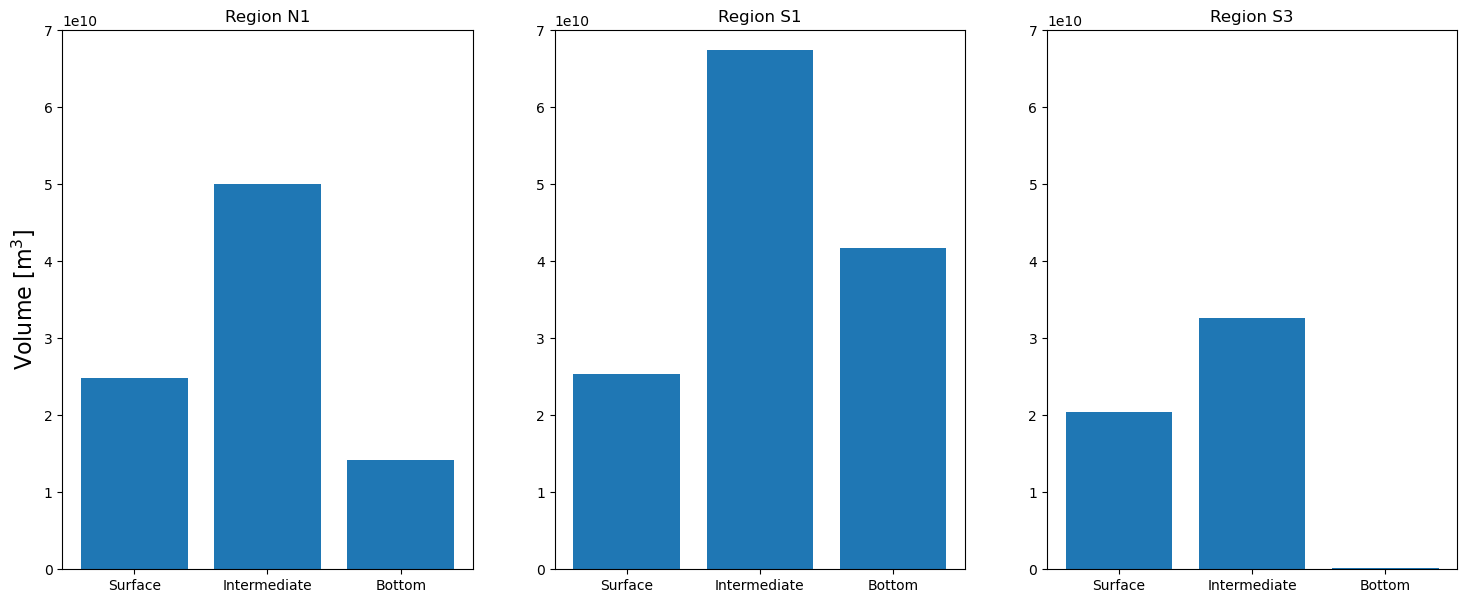

In [19]:
fig, ax = plt.subplots(1,3, figsize = (18, 7))
ax[0].bar(['Surface', 'Intermediate', 'Bottom'], [volume_N1_surface, volume_N1_intermediate, volume_N1_bottom]); ax[0].set_title('Region N1')
ax[1].bar(['Surface', 'Intermediate', 'Bottom'], [volume_S1_surface, volume_S1_intermediate, volume_S1_bottom]); ax[1].set_title('Region S1')
ax[2].bar(['Surface', 'Intermediate', 'Bottom'], [volume_S3_surface, volume_S3_intermediate, volume_S3_bottom]); ax[2].set_title('Region S3')
ax[0].set_ylabel(r'Volume [m$^{3}$]', fontsize = 16)
for axis in ax:
    axis.set_ylim(0,7e10)

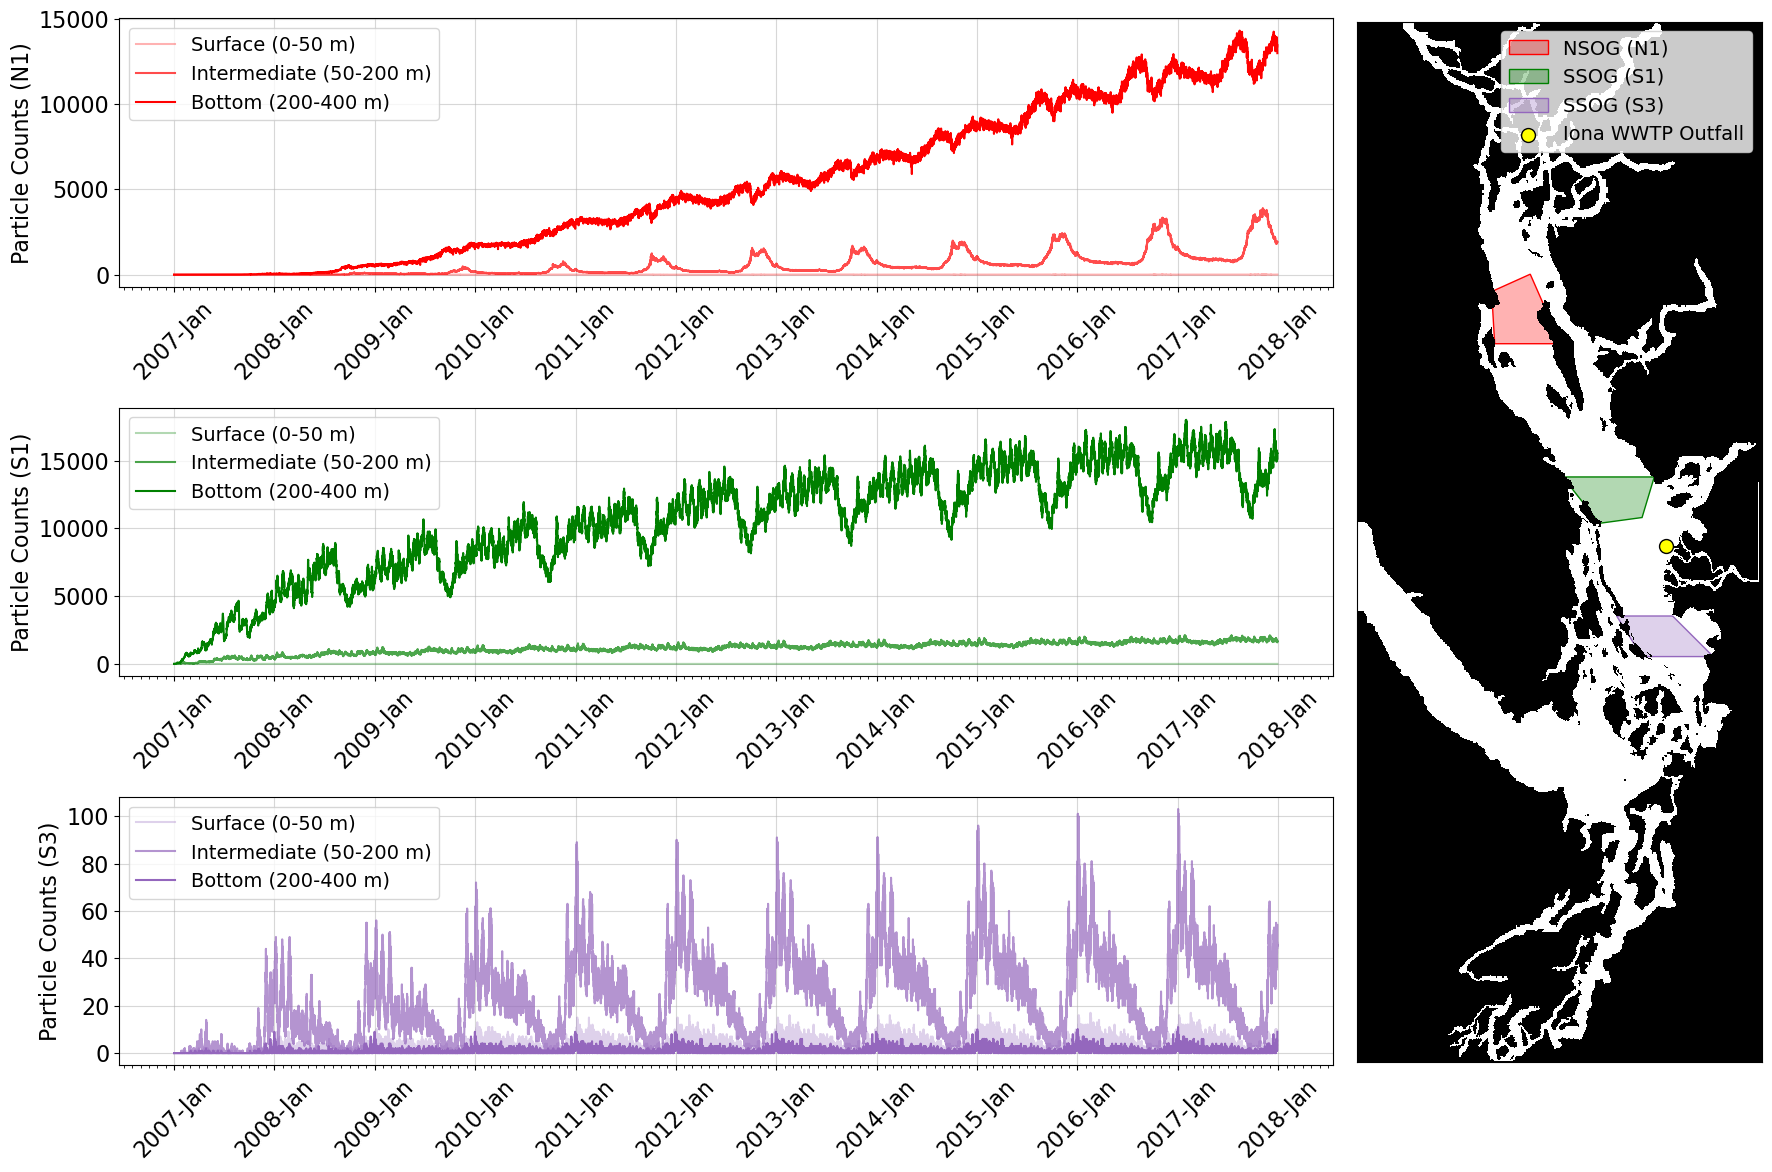

In [20]:
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap

plt.rcParams.update({'font.size': 16})
colors = [(0, 0, 0, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)

# 1. SETUP GRIDSPEC INSTEAD OF STANDARD SUBPLOTS
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, width_ratios=[3, 1])

# 2. ASSIGN AXES TO GRID CELLS
ax0 = fig.add_subplot(gs[0, 0])  # Row 0, Col 0
ax1 = fig.add_subplot(gs[1, 0])  # Row 1, Col 0
ax2 = fig.add_subplot(gs[2, 0])  # Row 2, Col 0
ax_map = fig.add_subplot(gs[:, 1]) # All rows (:), Col 1

# 3. PLOT TIME SERIES (Left Column)
ax0.plot(time_6h, total_timeseries_surface_N1, 'r', alpha=.3, label='Surface (0-50 m)') 
ax0.plot(time_6h, total_timeseries_intermediate_N1, 'r', alpha=.7, label='Intermediate (50-200 m)') 
ax0.plot(time_6h, total_timeseries_bottom_N1, 'r', label='Bottom (200-400 m)')

ax0.set_ylabel('Particle Counts (N1)')
ax1.plot(time_6h, total_timeseries_surface_S1, 'g', alpha=.3, label='Surface (0-50 m)') 
ax1.plot(time_6h, total_timeseries_intermediate_S1, 'g', alpha=.7, label='Intermediate (50-200 m)') 
ax1.plot(time_6h, total_timeseries_bottom_S1, 'g', label='Bottom (200-400 m)')
ax1.set_ylabel('Particle Counts (S1)')
ax2.plot(time_6h, total_timeseries_surface_S3, 'tab:purple', alpha=.3, label='Surface (0-50 m)') 
ax2.plot(time_6h, total_timeseries_intermediate_S3, 'tab:purple', alpha=.7, label='Intermediate (50-200 m)') 
ax2.plot(time_6h, total_timeseries_bottom_S3, 'tab:purple', label='Bottom (200-400 m)')
ax2.set_ylabel('Particle Counts (S3)')
# Format left column axes
for axis in [ax0, ax1, ax2]:
    axis.xaxis.set_major_locator(mdates.YearLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    axis.xaxis.set_minor_locator(mdates.MonthLocator(interval=1)) 
    axis.grid(True, alpha=0.5)
    axis.legend(fontsize=14, loc='upper left')
    axis.tick_params(axis='x', rotation=45)

# 4. PLOT MAP (Right Column, spans all rows)
# Note: Replaced all 'axes[:,1]' with 'ax_map'
plot_polygon(polygon_N1, ax=ax_map, color='r', label='NSOG (N1)', add_points=False)
plot_polygon(polygon_S1, ax=ax_map, color='g', label='SSOG (S1)', add_points=False)
plot_polygon(polygon_S3, ax=ax_map, color='tab:purple', label='SSOG (S3)', add_points=False)

ax_map.pcolormesh(mask['tmask'][0][0], cmap=cmap)

## Source ##
source_lat = 49.195045
source_lon = -123.301956
# Note: Removed the duplicate finder2 line from your original code
s_y, s_x = finder2(source_lat, source_lon, mask) 

ax_map.scatter(s_x, s_y, color='yellow', edgecolor='black', s=100, zorder=5, label='Iona WWTP Outfall')

ax_map.tick_params(which='both', bottom=False, top=False, left=False, right=False,
                   labelbottom=False, labelleft=False)

f = 1.14
ax_map.set_aspect(f)
ax_map.legend(loc='upper right', fontsize=14)

plt.tight_layout()
plt.show()

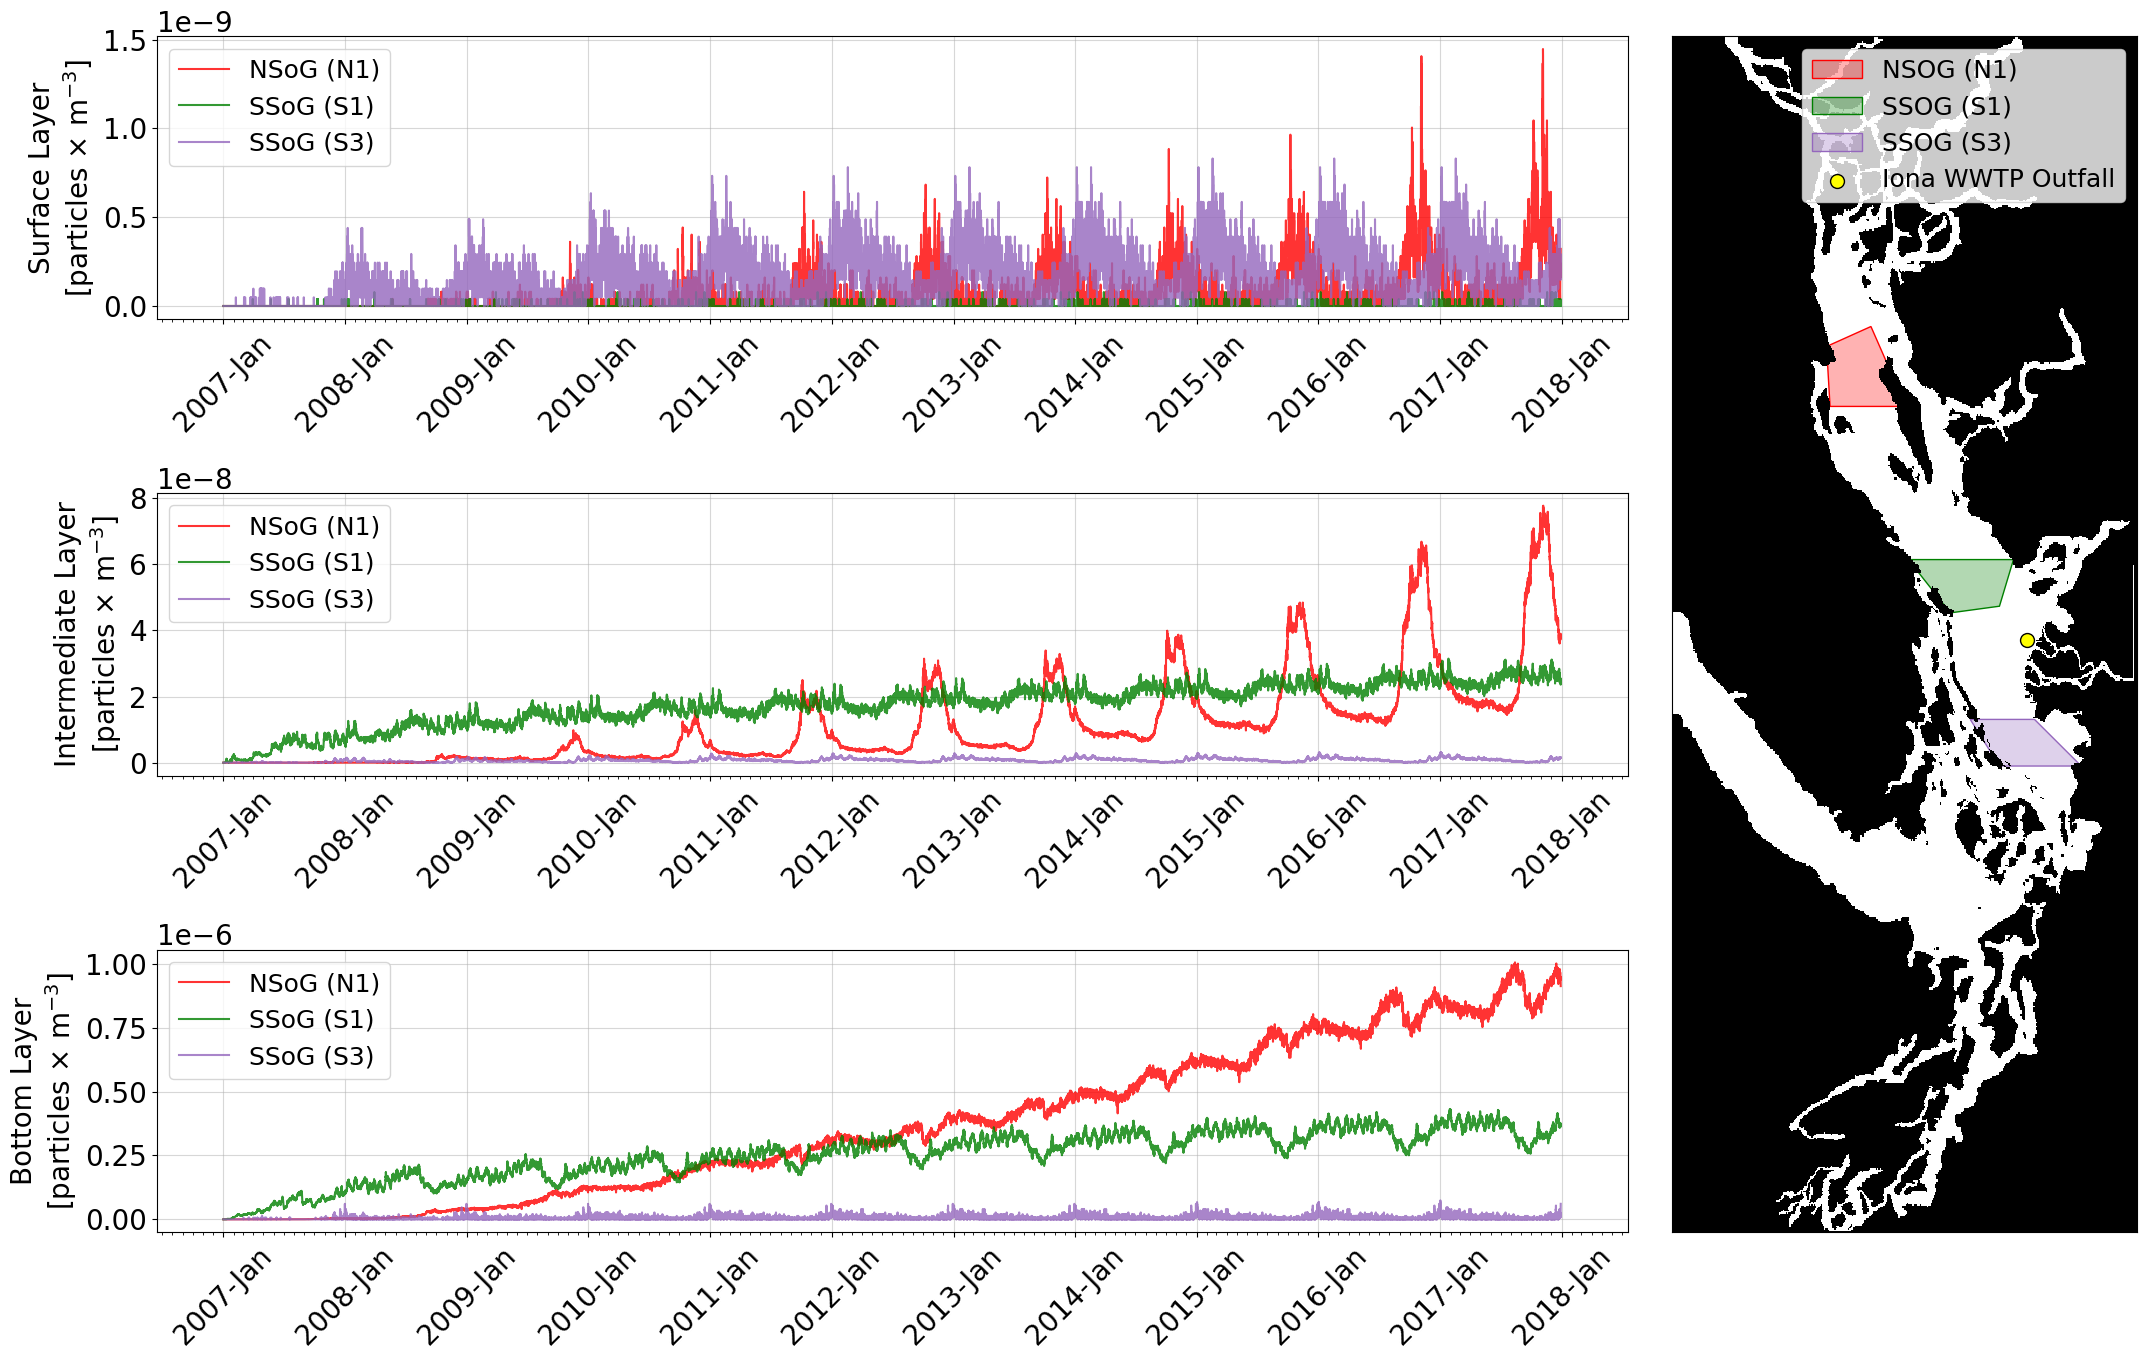

In [21]:
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap

plt.rcParams.update({'font.size': 20})
colors = [(0, 0, 0, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)

# 1. SETUP GRIDSPEC INSTEAD OF STANDARD SUBPLOTS
fig = plt.figure(figsize=(22, 14))
gs = fig.add_gridspec(3, 2, width_ratios=[3, 1])

# 2. ASSIGN AXES TO GRID CELLS
ax0 = fig.add_subplot(gs[0, 0])  # Row 0, Col 0
ax1 = fig.add_subplot(gs[1, 0])  # Row 1, Col 0
ax2 = fig.add_subplot(gs[2, 0])  # Row 2, Col 0
ax_map = fig.add_subplot(gs[:, 1]) # All rows (:), Col 1

# 3. PLOT TIME SERIES (Left Column)
ax0.plot(time_6h, total_timeseries_surface_N1 / volume_N1_surface, 'r', alpha = .8, label='NSoG (N1)') 
ax0.plot(time_6h, total_timeseries_surface_S1 / volume_S1_surface, 'g', alpha = .8, label='SSoG (S1)') 
ax0.plot(time_6h, total_timeseries_surface_S3 / volume_S3_surface, 'tab:purple', alpha = .8, label='SSoG (S3)') 
ax0.set_ylabel('Surface Layer' + '\n' + r'[particles $\times$ m$^{-3}$]')
#
ax1.plot(time_6h, total_timeseries_intermediate_N1 / volume_N1_intermediate, 'r', alpha = .8, label='NSoG (N1)') 
ax1.plot(time_6h, total_timeseries_intermediate_S1 / volume_S1_intermediate, 'g', alpha = .8, label='SSoG (S1)') 
ax1.plot(time_6h, total_timeseries_intermediate_S3 / volume_S3_intermediate, 'tab:purple', alpha = .8, label='SSoG (S3)') 
ax1.set_ylabel('Intermediate Layer' + '\n' + r'[particles $\times$ m$^{-3}$]')
#
ax2.plot(time_6h, total_timeseries_bottom_N1 / volume_N1_bottom, 'r', alpha = .8, label='NSoG (N1)') 
ax2.plot(time_6h, total_timeseries_bottom_S1 / volume_S1_bottom, 'g', alpha = .8, label='SSoG (S1)') 
ax2.plot(time_6h, total_timeseries_bottom_S3 / volume_S3_bottom, 'tab:purple', alpha = .8, label='SSoG (S3)') 
ax2.set_ylabel('Bottom Layer' + '\n' + r'[particles $\times$ m$^{-3}$]')
# Format left column axes
for axis in [ax0, ax1, ax2]:
    axis.xaxis.set_major_locator(mdates.YearLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    axis.xaxis.set_minor_locator(mdates.MonthLocator(interval=1)) 
    axis.grid(True, alpha=0.5)
    axis.legend(fontsize=18, loc='upper left')
    axis.tick_params(axis='x', rotation=45)

# 4. PLOT MAP (Right Column, spans all rows)
# Note: Replaced all 'axes[:,1]' with 'ax_map'
plot_polygon(polygon_N1, ax=ax_map, color='r', label='NSOG (N1)', add_points=False)
plot_polygon(polygon_S1, ax=ax_map, color='g', label='SSOG (S1)', add_points=False)
plot_polygon(polygon_S3, ax=ax_map, color='tab:purple', label='SSOG (S3)', add_points=False)

ax_map.pcolormesh(mask['tmask'][0][0], cmap=cmap)

## Source ##
source_lat = 49.195045
source_lon = -123.301956
# Note: Removed the duplicate finder2 line from your original code
s_y, s_x = finder2(source_lat, source_lon, mask) 

ax_map.scatter(s_x, s_y, color='yellow', edgecolor='black', s=100, zorder=5, label='Iona WWTP Outfall')

ax_map.tick_params(which='both', bottom=False, top=False, left=False, right=False,
                   labelbottom=False, labelleft=False)

f = 1.14
ax_map.set_aspect(f)
ax_map.legend(loc='upper right', fontsize=18)

plt.tight_layout()
plt.show()